# Experimentos de Aprendizaje por Refuerzo: Tres en Raya

## Basado en `01_introduccion.ipynb`

Este notebook explora en profundidad los conceptos fundamentales del **Aprendizaje por Refuerzo (axr)** usando el juego del tres en raya como entorno de experimentación, partiendo del código base del notebook de introducción.

### Conceptos de axr que exploraremos:

1. **Exploración vs Explotación** - El balance fundamental del axr
2. **Learning Rate (α)** - Cómo de rápido aprende el agente
3. **Función de Valor** - Estimación de probabilidad de ganar desde cada estado
4. **Convergencia** - Cuándo el agente deja de mejorar
5. **Política Óptima** - La mejor estrategia encontrada
6. **Complejidad del Entorno** - Efecto del tamaño del tablero
7. **Decaimiento de Exploración** - Explorar menos conforme se aprende
8. **TD Error** - La señal fundamental de aprendizaje

## Marco Teórico del Aprendizaje por Refuerzo

### Elementos del axr en nuestro problema:

- **Agente**: El jugador que aprende (X)
- **Entorno**: El tablero de juego + oponente (O)
- **Estado (S)**: Configuración actual del tablero
- **Acción (A)**: Colocar una ficha en una casilla vacía
- **Recompensa (R)**: 1 (victoria), 0.5 (empate), 0 (derrota)
- **Política (π)**: Estrategia que mapea estados a acciones
- **Función de Valor V(S)**: Probabilidad estimada de ganar desde S

### Regla de actualización (Temporal Difference Learning):

$$V(S_t) \leftarrow V(S_t) + \alpha [V(S_{t+1}) - V(S_t)]$$

Donde:
- $\alpha$ es el **learning rate** (0 < α ≤ 1)
- $V(S_{t+1}) - V(S_t)$ es el **error de predicción temporal (TD error)**
- El agente aprende corrigiendo sus estimaciones basándose en la diferencia entre lo esperado y lo observado

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import pickle
import time
import copy

%matplotlib inline

np.random.seed(42)

In [2]:
class Board():
    def __init__(self, rows=3, cols=3, win_length=3):
        self.rows = rows
        self.cols = cols
        self.win_length = win_length
        self.state = np.zeros((rows, cols))

    def valid_moves(self):
        return [(i, j) for i in range(self.rows) for j in range(self.cols) if self.state[i, j] == 0]

    def update(self, symbol, row, col):
        if self.state[row, col] == 0:
            self.state[row, col] = symbol
        else:
            raise ValueError("movimiento ilegal!")

    def _check_line(self, values):
        for symbol in [1, -1]:
            count = 0
            for v in values:
                if v == symbol:
                    count += 1
                    if count >= self.win_length:
                        return symbol
                else:
                    count = 0
        return None

    def is_game_over(self):
        for i in range(self.rows):
            result = self._check_line(self.state[i, :])
            if result is not None:
                return result
        for j in range(self.cols):
            result = self._check_line(self.state[:, j])
            if result is not None:
                return result
        for d in range(-(self.cols - self.win_length), self.rows - self.win_length + 1):
            diag = self.state.diagonal(d)
            result = self._check_line(diag)
            if result is not None:
                return result
        flipped = np.fliplr(self.state)
        for d in range(-(self.cols - self.win_length), self.rows - self.win_length + 1):
            diag = flipped.diagonal(d)
            result = self._check_line(diag)
            if result is not None:
                return result
        if len(self.valid_moves()) == 0:
            return 0
        return None

    def reset(self):
        self.state = np.zeros((self.rows, self.cols))

    def state_key(self):
        return str(self.state.reshape(self.rows * self.cols))

    def copy(self):
        new_board = Board(self.rows, self.cols, self.win_length)
        new_board.state = self.state.copy()
        return new_board


In [3]:
class Game():
    def __init__(self, player1, player2, rows=3, cols=3, win_length=3):
        player1.symbol = 1
        player2.symbol = -1
        self.players = [player1, player2]
        self.board = Board(rows=rows, cols=cols, win_length=win_length)

    def selfplay(self, rounds=100):
        wins = [0, 0]
        draws = 0
        for i in range(1, rounds + 1):
            self.board.reset()
            for player in self.players:
                player.reset()
            game_over = False
            while not game_over:
                for player in self.players:
                    action = player.move(self.board)
                    self.board.update(player.symbol, action[0], action[1])
                    for p in self.players:
                        p.update(self.board)
                    if self.board.is_game_over() is not None:
                        game_over = True
                        break
            result = self.board.is_game_over()
            self.reward()
            for ix, player in enumerate(self.players):
                if result == player.symbol:
                    wins[ix] += 1
            if result == 0:
                draws += 1
        return wins, draws

    def reward(self):
        winner = self.board.is_game_over()
        if winner == 0:
            for player in self.players:
                player.reward(0.5)
        else:
            for player in self.players:
                if winner == player.symbol:
                    player.reward(1)
                else:
                    player.reward(0)




In [4]:
class Agent():
    def __init__(self, alpha=0.5, prob_exp=0.5):
        self.value_function = {}
        self.alpha = alpha
        self.positions = []
        self.prob_exp = prob_exp
        self.symbol = 1
        self.history_rewards = []

    def reset(self):
        self.positions = []

    def move(self, board, explore=True):
        valid_moves = board.valid_moves()
        if explore and np.random.uniform(0, 1) < self.prob_exp:
            ix = np.random.choice(len(valid_moves))
            return valid_moves[ix]

        max_value = -1000
        best_row, best_col = valid_moves[0]
        for row, col in valid_moves:
            next_board = board.state.copy()
            next_board[row, col] = self.symbol
            next_state = str(next_board.reshape(board.rows * board.cols))
            value = self.value_function.get(next_state, 0)
            if value >= max_value:
                max_value = value
                best_row, best_col = row, col
        return best_row, best_col

    def update(self, board):
        self.positions.append(board.state_key())

    def reward(self, reward):
        self.history_rewards.append(reward)
        for p in reversed(self.positions):
            if self.value_function.get(p) is None:
                self.value_function[p] = 0
            self.value_function[p] += self.alpha * (reward - self.value_function[p])
            reward = self.value_function[p]

    def num_states(self):
        return len(self.value_function)

    def get_avg_reward_last_n(self, n=100):
        if len(self.history_rewards) < n:
            return np.mean(self.history_rewards)
        return np.mean(self.history_rewards[-n:])

##  Efecto del Learning Rate (α)

### Concepto axr: Velocidad de aprendizaje

El **learning rate** controla cuánto peso damos a la nueva información vs la antigua:

- **α pequeño (0.01)**: Aprende lento, pero estable. Requiere muchas iteraciones.
- **α medio (0.1-0.5)**: Balance entre velocidad y estabilidad.
- **α grande (0.9)**: Aprende rápido, pero puede ser inestable y olvidar lo aprendido.

En el límite:
- α → 0: El agente nunca aprende
- α → 1: El agente solo recuerda la última experiencia

In [5]:
learning_rates = [0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 0.9, 0.99]
results_lr = []

print("Experimento 1: Efecto del Learning Rate")
print("="*60)

for lr in learning_rates:
    agent1 = Agent(alpha=lr, prob_exp=0.5)
    agent2 = Agent(alpha=lr, prob_exp=0.5)
    
    game = Game(agent1, agent2, rows=3, cols=3, win_length=3)
    wins, draws = game.selfplay(10000)
    
    results_lr.append({
        'alpha': lr,
        'victorias_p1': wins[0],
        'victorias_p2': wins[1],
        'empates': draws,
        'estados': agent1.num_states()
    })
    print(f"α={lr:.2f} | P1: {wins[0]:>4} | P2: {wins[1]:>4} | Empates: {draws:>4} | Estados: {agent1.num_states():>5}")

df_lr = pd.DataFrame(results_lr)
df_lr

Experimento 1: Efecto del Learning Rate
α=0.01 | P1: 6642 | P2: 2841 | Empates:  517 | Estados:  4091
α=0.05 | P1: 5832 | P2: 3415 | Empates:  753 | Estados:  4101
α=0.10 | P1: 5745 | P2: 3579 | Empates:  676 | Estados:  4148
α=0.30 | P1: 5877 | P2: 2499 | Empates: 1624 | Estados:  4414
α=0.50 | P1: 5625 | P2: 2588 | Empates: 1787 | Estados:  4687
α=0.70 | P1: 5688 | P2: 2744 | Empates: 1568 | Estados:  5124
α=0.90 | P1: 5660 | P2: 2909 | Empates: 1431 | Estados:  5240
α=0.99 | P1: 5616 | P2: 2912 | Empates: 1472 | Estados:  5218


,alpha,victorias_p1,victorias_p2,empates,estados
0,0.01,6642,2841,517,4091
1,0.05,5832,3415,753,4101
2,0.10,5745,3579,676,4148
3,0.30,5877,2499,1624,4414
4,0.50,5625,2588,1787,4687
5,0.70,5688,2744,1568,5124
6,0.90,5660,2909,1431,5240
7,0.99,5616,2912,1472,5218


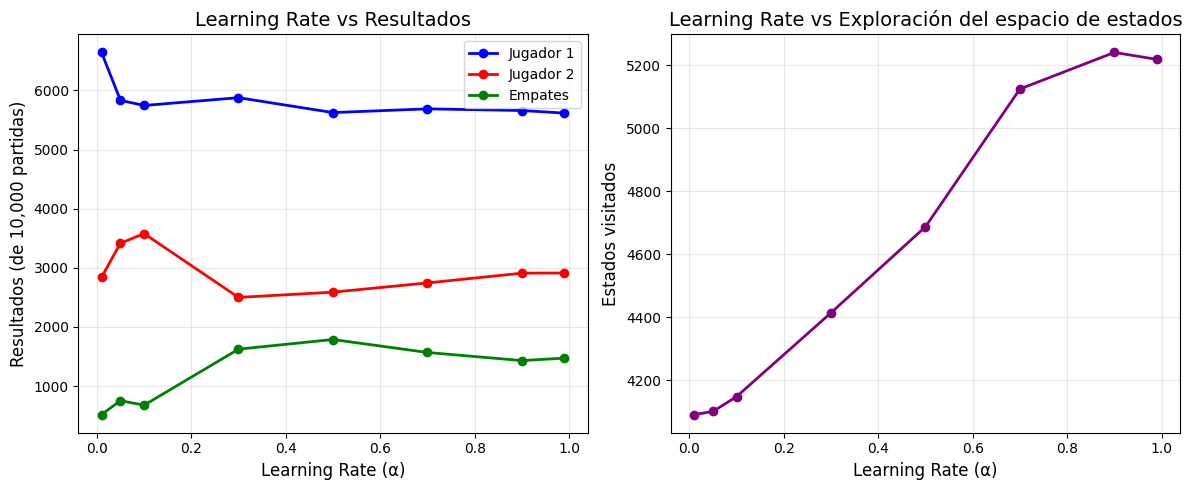

In [6]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(df_lr['alpha'], df_lr['victorias_p1'], 'b-o', label='Jugador 1', linewidth=2)
plt.plot(df_lr['alpha'], df_lr['victorias_p2'], 'r-o', label='Jugador 2', linewidth=2)
plt.plot(df_lr['alpha'], df_lr['empates'], 'g-o', label='Empates', linewidth=2)
plt.xlabel('Learning Rate (α)', fontsize=12)
plt.ylabel('Resultados (de 10,000 partidas)', fontsize=12)
plt.title('Learning Rate vs Resultados', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(df_lr['alpha'], df_lr['estados'], 'purple', marker='o', linewidth=2)
plt.xlabel('Learning Rate (α)', fontsize=12)
plt.ylabel('Estados visitados', fontsize=12)
plt.title('Learning Rate vs Exploración del espacio de estados', fontsize=14)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Experimento 2: Efecto del Ratio de Exploración (ε)

### Concepto axr: Exploración vs Explotación

Este es el **problema fundamental del axr**: ¿debo usar lo que ya sé (explotar) o probar algo nuevo (explorar)?

- **ε = 0**: Solo explota. Nunca descubre mejores estrategias.
- **ε = 1**: Solo explora. Comportamiento aleatorio puro.
- **ε óptimo**: Balance que permite descubrir y aprovechar el conocimiento.

En la práctica, se usa **ε-decay**: empezar con ε alto e ir reduciéndolo.

In [7]:
exploration_rates = [0.0, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
results_exp = []

print("Experimento 2: Efecto del Ratio de Exploración")
print("="*60)

for eps in exploration_rates:
    agent1 = Agent(alpha=0.5, prob_exp=eps)
    agent2 = Agent(alpha=0.5, prob_exp=eps)
    
    game = Game(agent1, agent2, rows=3, cols=3, win_length=3)
    wins, draws = game.selfplay(10000)
    
    results_exp.append({
        'epsilon': eps,
        'victorias_p1': wins[0],
        'victorias_p2': wins[1],
        'empates': draws,
        'estados': agent1.num_states()
    })
    print(f"ε={eps:.2f} | P1: {wins[0]:>4} | P2: {wins[1]:>4} | Empates: {draws:>4} | Estados: {agent1.num_states():>5}")

df_exp = pd.DataFrame(results_exp)


Experimento 2: Efecto del Ratio de Exploración
ε=0.00 | P1: 10000 | P2:    0 | Empates:    0 | Estados:     7
ε=0.05 | P1: 3109 | P2:  773 | Empates: 6118 | Estados:  1617
ε=0.10 | P1: 3974 | P2: 1069 | Empates: 4957 | Estados:  2055
ε=0.20 | P1: 4932 | P2: 1732 | Empates: 3336 | Estados:  3376
ε=0.30 | P1: 4663 | P2: 2579 | Empates: 2758 | Estados:  3845
ε=0.40 | P1: 5758 | P2: 2143 | Empates: 2099 | Estados:  4263
ε=0.50 | P1: 5547 | P2: 2809 | Empates: 1644 | Estados:  4869
ε=0.60 | P1: 5853 | P2: 2697 | Empates: 1450 | Estados:  5098
ε=0.70 | P1: 5856 | P2: 2842 | Empates: 1302 | Estados:  5344
ε=0.80 | P1: 5800 | P2: 2993 | Empates: 1207 | Estados:  5419
ε=0.90 | P1: 5833 | P2: 2921 | Empates: 1246 | Estados:  5468
ε=1.00 | P1: 5840 | P2: 2927 | Empates: 1233 | Estados:  5475


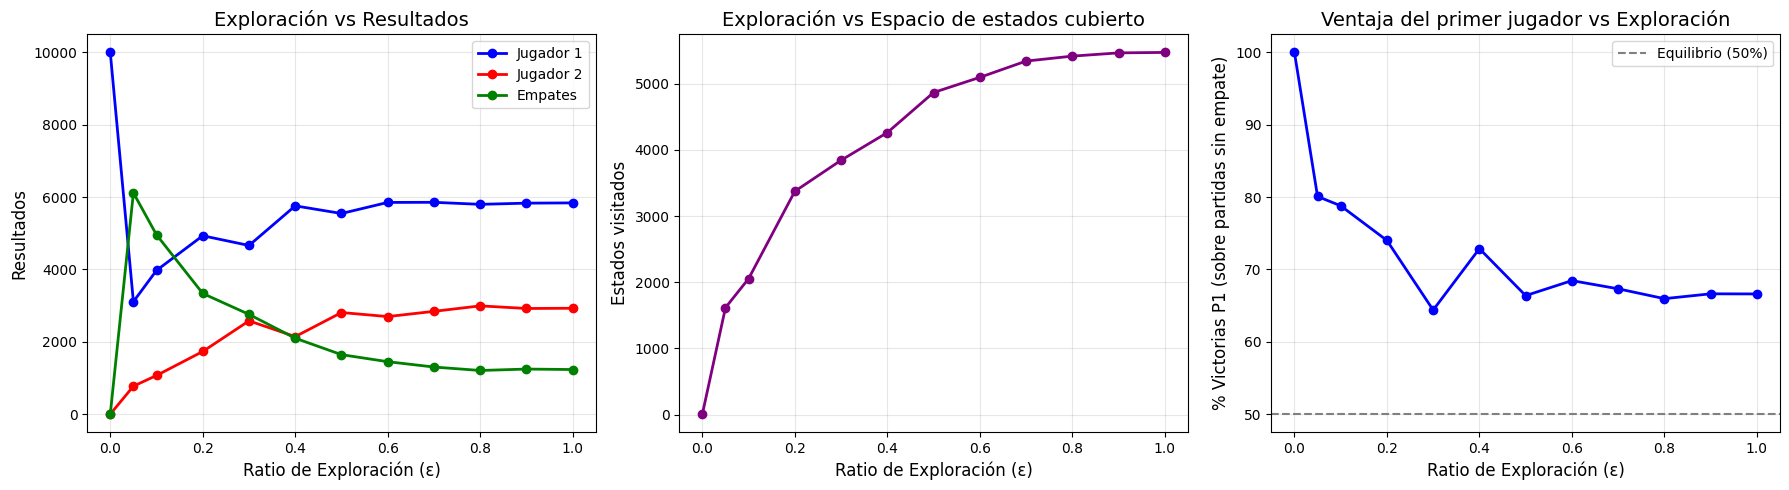

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(df_exp['epsilon'], df_exp['victorias_p1'], 'b-o', label='Jugador 1', linewidth=2)
axes[0].plot(df_exp['epsilon'], df_exp['victorias_p2'], 'r-o', label='Jugador 2', linewidth=2)
axes[0].plot(df_exp['epsilon'], df_exp['empates'], 'g-o', label='Empates', linewidth=2)
axes[0].set_xlabel('Ratio de Exploración (ε)', fontsize=12)
axes[0].set_ylabel('Resultados', fontsize=12)
axes[0].set_title('Exploración vs Resultados', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_exp['epsilon'], df_exp['estados'], 'purple', marker='o', linewidth=2)
axes[1].set_xlabel('Ratio de Exploración (ε)', fontsize=12)
axes[1].set_ylabel('Estados visitados', fontsize=12)
axes[1].set_title('Exploración vs Espacio de estados cubierto', fontsize=14)
axes[1].grid(True, alpha=0.3)

df_exp['total_no_empate'] = df_exp['victorias_p1'] + df_exp['victorias_p2']
axes[2].plot(df_exp['epsilon'], df_exp['victorias_p1'] / df_exp['total_no_empate'] * 100, 'b-o', linewidth=2)
axes[2].axhline(y=50, color='gray', linestyle='--', label='Equilibrio (50%)')
axes[2].set_xlabel('Ratio de Exploración (ε)', fontsize=12)
axes[2].set_ylabel('% Victorias P1 (sobre partidas sin empate)', fontsize=12)
axes[2].set_title('Ventaja del primer jugador vs Exploración', fontsize=14)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Experimento 3: Convergencia del aprendizaje a lo largo del tiempo

### Concepto axr: Curva de aprendizaje

En axr, es crucial entender **cómo mejora el agente con el tiempo**. Analizamos:

- **Velocidad de convergencia**: ¿Cuántas partidas necesita para aprender bien?
- **Estabilidad**: ¿Una vez que aprende, mantiene su nivel?
- **Techo de rendimiento**: ¿Cuál es el máximo que puede alcanzar?

In [9]:
def track_learning_curve(alpha=0.5, prob_exp=0.5, total_rounds=50000, window=500):
    agent1 = Agent(alpha=alpha, prob_exp=prob_exp)
    agent2 = Agent(alpha=alpha, prob_exp=prob_exp)
    
    game = Game(agent1, agent2, rows=3, cols=3, win_length=3)
    
    p1_wins_cum = []
    p2_wins_cum = []
    draws_cum = []
    states_cum = []
    avg_reward_p1 = []
    
    p1_wins = 0
    p2_wins = 0
    draws = 0
    
    for i in tqdm(range(1, total_rounds + 1), leave=False):
        game.board.reset()
        agent1.reset()
        agent2.reset()
        
        game_over = False
        while not game_over:
            for player in game.players:
                action = player.move(game.board)
                game.board.update(player.symbol, action[0], action[1])
                for p in game.players:
                    p.update(game.board)
                if game.board.is_game_over() is not None:
                    game_over = True
                    break
        
        result = game.board.is_game_over()
        game.reward()
        
        if result == 1:
            p1_wins += 1
        elif result == -1:
            p2_wins += 1
        else:
            draws += 1
        
        if i % window == 0:
            p1_wins_cum.append(p1_wins)
            p2_wins_cum.append(p2_wins)
            draws_cum.append(draws)
            states_cum.append(agent1.num_states())
            avg_reward_p1.append(agent1.get_avg_reward_last_n(window))
    
    return {
        'rounds': list(range(window, total_rounds + 1, window)),
        'p1_wins': p1_wins_cum,
        'p2_wins': p2_wins_cum,
        'draws': draws_cum,
        'states': states_cum,
        'avg_reward_p1': avg_reward_p1
    }, agent1, agent2


print("Experimento 3: Curva de aprendizaje (50,000 partidas)")
print("="*60)

curve_data, agent1_final, agent2_final = track_learning_curve(
    alpha=0.5, prob_exp=0.5, total_rounds=50000, window=500
)



Experimento 3: Curva de aprendizaje (50,000 partidas)


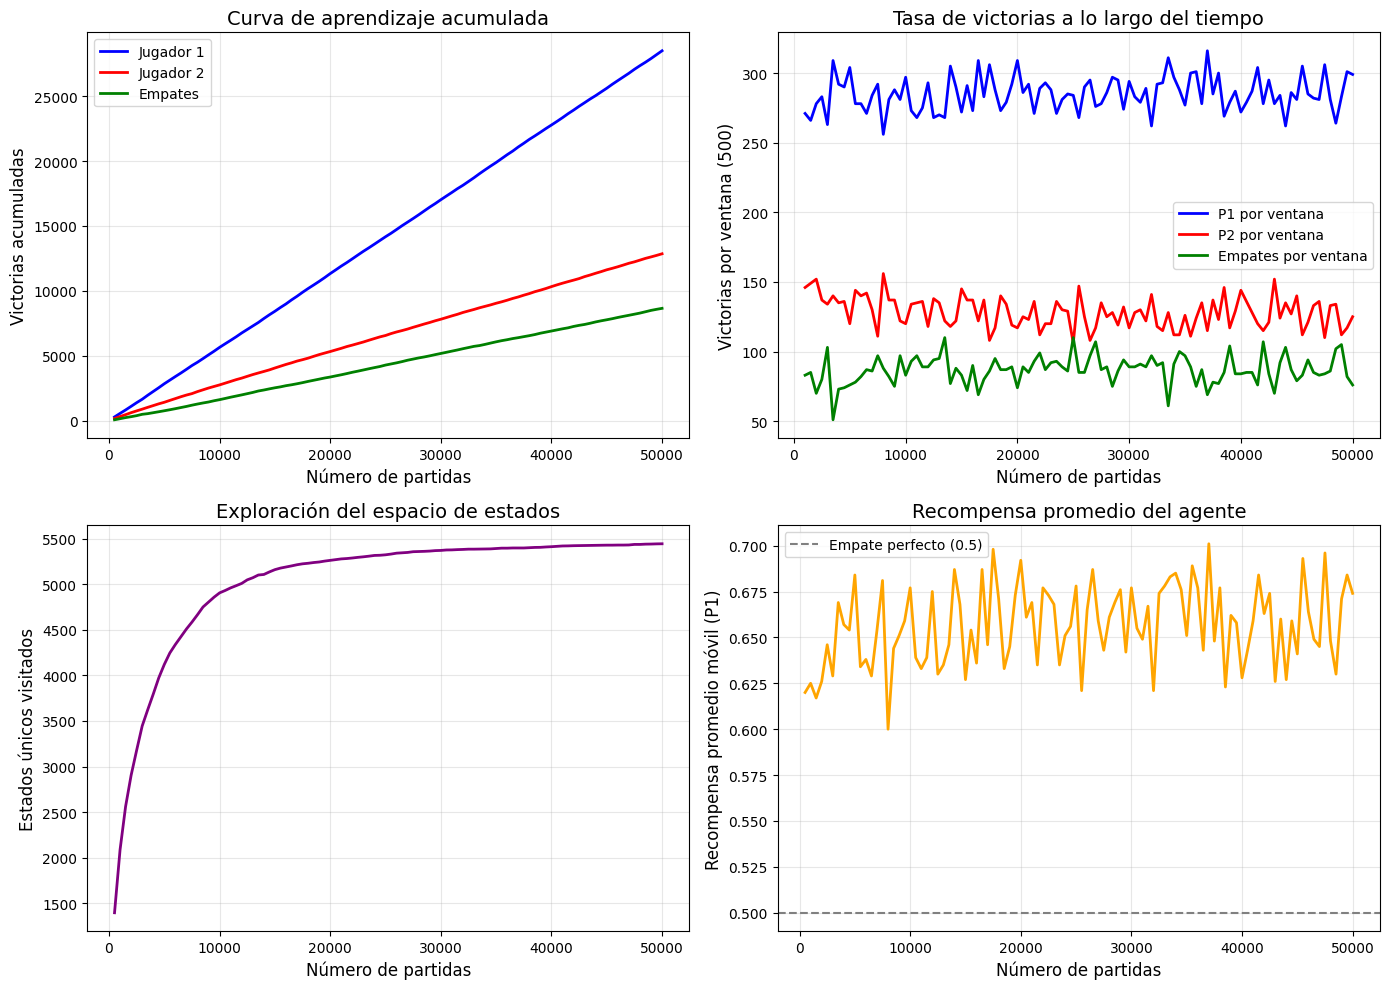

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(curve_data['rounds'], curve_data['p1_wins'], 'b-', label='Jugador 1', linewidth=2)
axes[0, 0].plot(curve_data['rounds'], curve_data['p2_wins'], 'r-', label='Jugador 2', linewidth=2)
axes[0, 0].plot(curve_data['rounds'], curve_data['draws'], 'g-', label='Empates', linewidth=2)
axes[0, 0].set_xlabel('Número de partidas', fontsize=12)
axes[0, 0].set_ylabel('Victorias acumuladas', fontsize=12)
axes[0, 0].set_title('Curva de aprendizaje acumulada', fontsize=14)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

p1_diff = np.diff(curve_data['p1_wins'])
p2_diff = np.diff(curve_data['p2_wins'])
draw_diff = np.diff(curve_data['draws'])
axes[0, 1].plot(curve_data['rounds'][1:], p1_diff, 'b-', label='P1 por ventana', linewidth=2)
axes[0, 1].plot(curve_data['rounds'][1:], p2_diff, 'r-', label='P2 por ventana', linewidth=2)
axes[0, 1].plot(curve_data['rounds'][1:], draw_diff, 'g-', label='Empates por ventana', linewidth=2)
axes[0, 1].set_xlabel('Número de partidas', fontsize=12)
axes[0, 1].set_ylabel('Victorias por ventana (500)', fontsize=12)
axes[0, 1].set_title('Tasa de victorias a lo largo del tiempo', fontsize=14)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(curve_data['rounds'], curve_data['states'], 'purple', linewidth=2)
axes[1, 0].set_xlabel('Número de partidas', fontsize=12)
axes[1, 0].set_ylabel('Estados únicos visitados', fontsize=12)
axes[1, 0].set_title('Exploración del espacio de estados', fontsize=14)
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(curve_data['rounds'], curve_data['avg_reward_p1'], 'orange', linewidth=2)
axes[1, 1].axhline(y=0.5, color='gray', linestyle='--', label='Empate perfecto (0.5)')
axes[1, 1].set_xlabel('Número de partidas', fontsize=12)
axes[1, 1].set_ylabel('Recompensa promedio móvil (P1)', fontsize=12)
axes[1, 1].set_title('Recompensa promedio del agente', fontsize=14)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Experimento 5: Tamaño del tablero y complejidad del entorno

### Concepto axr: Escalabilidad y maldición de la dimensionalidad

Uno de los mayores retos del axr es la **maldición de la dimensionalidad**: el espacio de estados crece exponencialmente con el tamaño del entorno.

| Tablero | Casillas | Estados teóricos (3^N) | Estados alcanzables |
|---------|----------|------------------------|---------------------|
| 3x3     | 9        | 19,683                 | ~5,478              |
| 4x3     | 12       | 531,441                | ~?                  |
| 4x4     | 16       | 43,046,721             | ~?                  |
| 5x5     | 25       | 847,288,609,443        | ~?                  |

Esto demuestra por qué los métodos basados en tablas (como el nuestro) no escalan, y por qué se necesitan **aproximadores de función** (redes neuronales → Deep RL).

In [20]:
board_configs = [
    (3, 3, 3, "3x3 clásico"),
    (3, 4, 3, "3x4 rectangular"),
    (4, 3, 3, "4x3 rectangular"),
    (4, 4, 3, "4x4 fácil (3 en línea)"),
    (4, 4, 4, "4x4 difícil (4 en línea)"),
]

results_board = []

print("Experimento 5: Efecto del tamaño del tablero")
print("="*70)

for rows, cols, win_length, name in board_configs:
    agent1 = Agent(alpha=0.5, prob_exp=0.5)
    agent2 = Agent(alpha=0.5, prob_exp=0.5)
    
    start_time = time.time()
    game = Game(agent1, agent2, rows=rows, cols=cols, win_length=win_length)
    wins, draws = game.selfplay(10000)
    elapsed = time.time() - start_time
    
    max_states = 3 ** (rows * cols)
    
    results_board.append({
        'config': name,
        'rows': rows,
        'cols': cols,
        'win_length': win_length,
        'casillas': rows * cols,
        'max_states': max_states,
        'victorias_p1': wins[0],
        'victorias_p2': wins[1],
        'empates': draws,
        'estados': agent1.num_states(),
        'tiempo': elapsed,
        'cobertura': agent1.num_states() / max_states * 100
    })
    print(f"{name:<25} | P1: {wins[0]:>4} | P2: {wins[1]:>4} | Emp: {draws:>4} | Est: {agent1.num_states():>7,} | {elapsed:>6.2f}s")

df_board = pd.DataFrame(results_board)


Experimento 5: Efecto del tamaño del tablero
3x3 clásico               | P1: 5308 | P2: 2912 | Emp: 1780 | Est:   4,737 |  24.42s
3x4 rectangular           | P1: 6414 | P2: 2854 | Emp:  732 | Est:  22,145 |  36.72s
4x3 rectangular           | P1: 6166 | P2: 3301 | Emp:  533 | Est:  24,053 |  36.20s
4x4 fácil (3 en línea)    | P1: 6216 | P2: 3775 | Emp:    9 | Est:  45,013 |  56.04s
4x4 difícil (4 en línea)  | P1: 3254 | P2: 2676 | Emp: 4070 | Est:  85,622 |  76.09s


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

x = np.arange(len(board_configs))
width = 0.25
axes[0, 0].bar(x - width, df_board['victorias_p1'], width, label='Jugador 1', color='steelblue')
axes[0, 0].bar(x, df_board['victorias_p2'], width, label='Jugador 2', color='coral')
axes[0, 0].bar(x + width, df_board['empates'], width, label='Empates', color='green')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(df_board['config'], rotation=45, ha='right')
axes[0, 0].set_ylabel('Resultados', fontsize=12)
axes[0, 0].set_title('Resultados por configuración de tablero', fontsize=14)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')

axes[0, 1].semilogy(df_board['casillas'], df_board['max_states'], 'ro-', linewidth=2, label='Estados teóricos (3^N)')
axes[0, 1].semilogy(df_board['casillas'], df_board['estados'], 'bs-', linewidth=2, label='Estados visitados')
axes[0, 1].set_xlabel('Número de casillas', fontsize=12)
axes[0, 1].set_ylabel('Estados (escala log)', fontsize=12)
axes[0, 1].set_title('Crecimiento exponencial del espacio de estados', fontsize=14)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(df_board['casillas'], df_board['cobertura'], 'purple', marker='o', linewidth=2)
axes[1, 0].set_xlabel('Número de casillas', fontsize=12)
axes[1, 0].set_ylabel('% del espacio cubierto', fontsize=12)
axes[1, 0].set_title('Cobertura del espacio de estados (10K partidas)', fontsize=14)
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(df_board['casillas'], df_board['tiempo'], 'orange', marker='o', linewidth=2)
axes[1, 1].set_xlabel('Número de casillas', fontsize=12)
axes[1, 1].set_ylabel('Tiempo (segundos)', fontsize=12)
axes[1, 1].set_title('Tiempo de entrenamiento por tamaño', fontsize=14)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

## Experimento 6: Agente experto vs oponente aleatorio

### Concepto axr: Transferencia y robustez de la política aprendida

¿Qué tan buena es la política aprendida? La probamos contra diferentes tipos de oponentes:

1. **Oponente aleatorio**: ¿Puede ganar siempre?
2. **Oponente con misma experiencia**: ¿Puede empatar?
3. **Oponente más experimentado**: ¿Puede aprender de uno mejor?

In [14]:
print("Experimento 6: Robustez de la política aprendida")
print("="*60)

print("\nFase 1: Entrenando agente experto (50,000 partidas)...")
expert = Agent(alpha=0.5, prob_exp=0.5)
opponent = Agent(alpha=0.5, prob_exp=0.5)
game = Game(expert, opponent, rows=3, cols=3, win_length=3)
wins, draws = game.selfplay(50000)
print(f"Entrenamiento completado. Estados aprendidos: {expert.num_states()}")

print("\nFase 2: Probando contra diferentes oponentes...")

opponents = [
    ("Aleatorio puro", Agent(alpha=0.5, prob_exp=1.0)),
    ("Poco explorador (ε=0.1)", Agent(alpha=0.5, prob_exp=0.1)),
    ("Misma experiencia", Agent(alpha=0.5, prob_exp=0.5)),
    ("Sin exploración (ε=0)", Agent(alpha=0.5, prob_exp=0.0)),
]

results_robust = []

for name, opp in opponents:
    expert_test = Agent(alpha=0.5, prob_exp=0.0)
    expert_test.value_function = expert.value_function.copy()
    
    game = Game(expert_test, opp, rows=3, cols=3, win_length=3)
    wins, draws = game.selfplay(5000)
    
    results_robust.append({
        'oponente': name,
        'victorias_experto': wins[0],
        'victorias_oponente': wins[1],
        'empates': draws,
        'tasa_victoria': wins[0] / 5000 * 100
    })
    print(f"vs {name:<25} | Experto: {wins[0]:>4} | Oponente: {wins[1]:>4} | Empates: {draws:>4} | %Victoria: {wins[0]/5000*100:.1f}%")

df_robust = pd.DataFrame(results_robust)

Experimento 6: Robustez de la política aprendida

Fase 1: Entrenando agente experto (50,000 partidas)...
Entrenamiento completado. Estados aprendidos: 5444

Fase 2: Probando contra diferentes oponentes...
vs Aleatorio puro            | Experto: 4950 | Oponente:    1 | Empates:   49 | %Victoria: 99.0%
vs Poco explorador (ε=0.1)   | Experto: 5000 | Oponente:    0 | Empates:    0 | %Victoria: 100.0%
vs Misma experiencia         | Experto: 4183 | Oponente:    6 | Empates:  811 | %Victoria: 83.7%
vs Sin exploración (ε=0)     | Experto: 5000 | Oponente:    0 | Empates:    0 | %Victoria: 100.0%


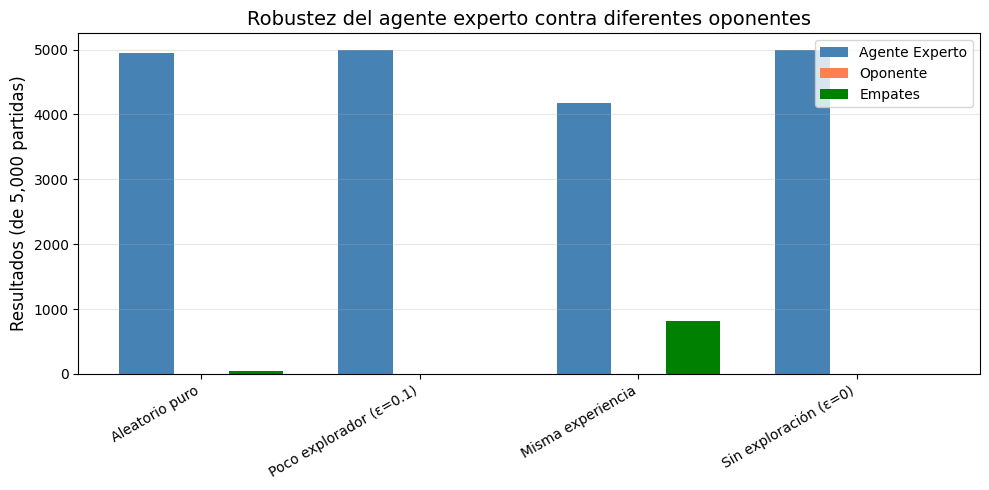

In [15]:
plt.figure(figsize=(10, 5))
x = np.arange(len(results_robust))
width = 0.25

plt.bar(x - width, df_robust['victorias_experto'], width, label='Agente Experto', color='steelblue')
plt.bar(x, df_robust['victorias_oponente'], width, label='Oponente', color='coral')
plt.bar(x + width, df_robust['empates'], width, label='Empates', color='green')
plt.xticks(x, df_robust['oponente'], rotation=30, ha='right')
plt.ylabel('Resultados (de 5,000 partidas)', fontsize=12)
plt.title('Robustez del agente experto contra diferentes oponentes', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Experimento 8: Encontrando la política óptima

### Concepto axr: Política óptima π*

La **política óptima** es la mejor estrategia posible. En tres en raya 3x3, sabemos que con juego perfecto siempre se empata. Vamos a:

1. Entrenar un agente muy experimentado
2. Extraer su política (mejor acción para cada estado)
3. Visualizar las decisiones del agente en estados clave
4. Verificar si descubre la estrategia de empate perfecto

Experimento 8: Extracción de la política óptima

Entrenando agente altamente experimentado (100,000 partidas)...

Resultados del entrenamiento:
  Jugador 1: 54789 victorias
  Jugador 2: 25736 victorias
  Empates: 19475
  Estados aprendidos: 5450

Análisis de la primera jugada óptima:

Valor de cada primera jugada posible:
  Posición (1, 1) ( centro): V = 0.7203
  Posición (2, 2) (esquina): V = 0.6506
  Posición (0, 0) (esquina): V = 0.6354
  Posición (2, 0) (esquina): V = 0.6112
  Posición (0, 2) (esquina): V = 0.6056
  Posición (2, 1) (   lado): V = 0.5403
  Posición (1, 2) (   lado): V = 0.5313
  Posición (1, 0) (   lado): V = 0.5162
  Posición (0, 1) (   lado): V = 0.5013


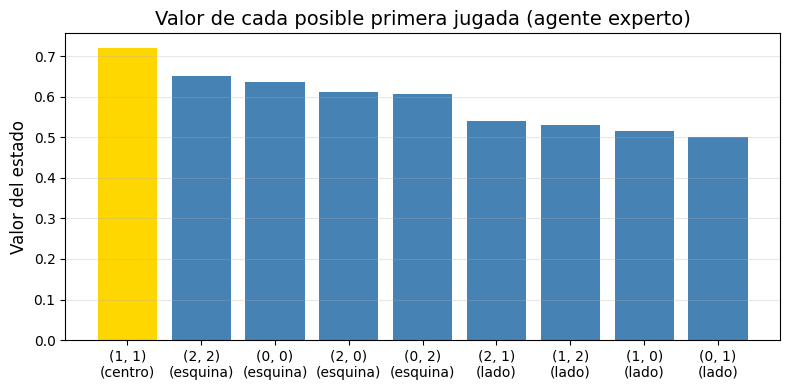


Conclusión: La mejor primera jugada es (1, 1) (centro)


In [16]:
print("Experimento 8: Extracción de la política óptima")
print("="*60)

print("\nEntrenando agente altamente experimentado (100,000 partidas)...")
expert_agent = Agent(alpha=0.3, prob_exp=0.5)
opponent = Agent(alpha=0.3, prob_exp=0.5)
game = Game(expert_agent, opponent, rows=3, cols=3, win_length=3)
wins, draws = game.selfplay(100000)

print(f"\nResultados del entrenamiento:")
print(f"  Jugador 1: {wins[0]} victorias")
print(f"  Jugador 2: {wins[1]} victorias")
print(f"  Empates: {draws}")
print(f"  Estados aprendidos: {expert_agent.num_states()}")

def get_best_action(agent, board_state, symbol=1):
    board = Board(3, 3, 3)
    board.state = board_state.copy()
    valid = board.valid_moves()
    
    best_value = -1000
    best_action = valid[0]
    
    for row, col in valid:
        next_state = board.state.copy()
        next_state[row, col] = symbol
        key = str(next_state.reshape(9))
        value = agent.value_function.get(key, 0)
        if value > best_value:
            best_value = value
            best_action = (row, col)
    
    return best_action, best_value


print("\nAnálisis de la primera jugada óptima:")
print("="*60)

empty_board = np.zeros((3, 3))
valid_moves = [(i, j) for i in range(3) for j in range(3)]

move_values = []
for row, col in valid_moves:
    next_state = empty_board.copy()
    next_state[row, col] = 1
    key = str(next_state.reshape(9))
    value = expert_agent.value_function.get(key, 0)
    move_values.append({'pos': (row, col), 'value': value, 'type': 'esquina' if (row in [0,2] and col in [0,2]) else ('centro' if (row, col) == (1, 1) else 'lado')})

df_moves = pd.DataFrame(move_values)
df_moves = df_moves.sort_values('value', ascending=False)

print("\nValor de cada primera jugada posible:")
for _, row in df_moves.iterrows():
    print(f"  Posición {row['pos']} ({row['type']:>7}): V = {row['value']:.4f}")

plt.figure(figsize=(8, 4))
positions = [f"{r['pos']}\n({r['type']})" for _, r in df_moves.iterrows()]
values = [r['value'] for _, r in df_moves.iterrows()]
colors = ['gold' if v == max(values) else 'steelblue' for v in values]
plt.bar(positions, values, color=colors)
plt.ylabel('Valor del estado', fontsize=12)
plt.title('Valor de cada posible primera jugada (agente experto)', fontsize=14)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f"\nConclusión: La mejor primera jugada es {df_moves.iloc[0]['pos']} ({df_moves.iloc[0]['type']})")

## Experimento 9: Grid de hiperparámetros (α vs ε)

### Concepto axr: Búsqueda de hiperparámetros óptimos

En axr, los **hiperparámetros** (α, ε, etc.) no se aprenden, se eligen. Encontrar la combinación óptima es crucial. Hacemos un **grid search** para encontrar la mejor combinación de learning rate y exploración.

Experimento 9: Grid de hiperparámetros (α vs ε)

Ejecutando grid search (5,000 partidas por combinación)...


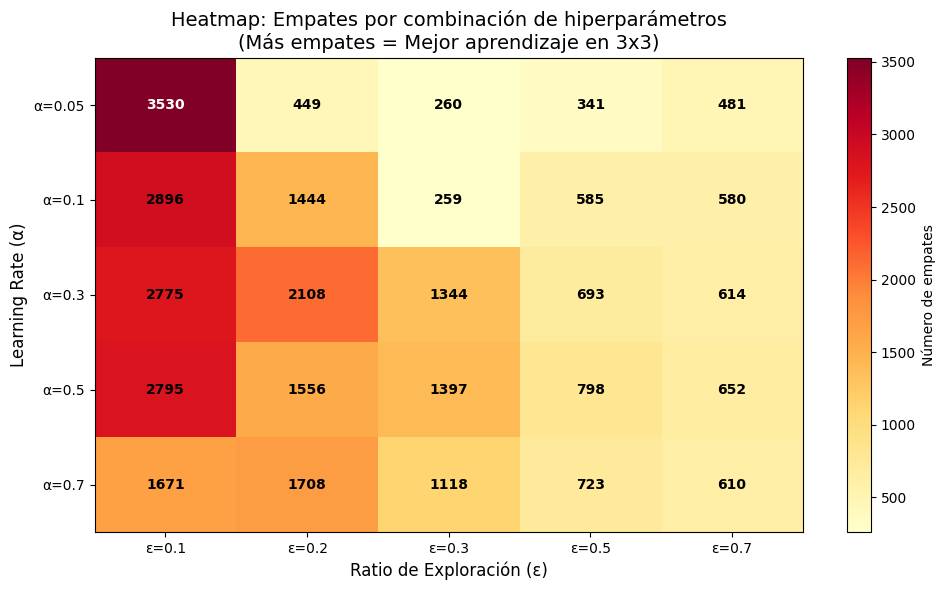


Mejor combinación: α=0.05, ε=0.1
Empates: 3530 de 5,000 (70.6%)


In [17]:
alphas = [0.05, 0.1, 0.3, 0.5, 0.7]
epsilons = [0.1, 0.2, 0.3, 0.5, 0.7]

grid_results = np.zeros((len(alphas), len(epsilons)))

print("Experimento 9: Grid de hiperparámetros (α vs ε)")
print("="*60)
print("\nEjecutando grid search (5,000 partidas por combinación)...")

for i, alpha in enumerate(alphas):
    for j, eps in enumerate(epsilons):
        agent1 = Agent(alpha=alpha, prob_exp=eps)
        agent2 = Agent(alpha=alpha, prob_exp=eps)
        game = Game(agent1, agent2, rows=3, cols=3, win_length=3)
        wins, draws = game.selfplay(5000)
        grid_results[i, j] = draws

plt.figure(figsize=(10, 6))
im = plt.imshow(grid_results, cmap='YlOrRd', aspect='auto')
plt.colorbar(im, label='Número de empates')
plt.xticks(range(len(epsilons)), [f"ε={e}" for e in epsilons])
plt.yticks(range(len(alphas)), [f"α={a}" for a in alphas])
plt.xlabel('Ratio de Exploración (ε)', fontsize=12)
plt.ylabel('Learning Rate (α)', fontsize=12)
plt.title('Heatmap: Empates por combinación de hiperparámetros\n(Más empates = Mejor aprendizaje en 3x3)', fontsize=14)

for i in range(len(alphas)):
    for j in range(len(epsilons)):
        plt.text(j, i, int(grid_results[i, j]), ha='center', va='center', 
                color='white' if grid_results[i, j] > 3000 else 'black', fontweight='bold')

plt.tight_layout()
plt.show()

best_idx = np.unravel_index(np.argmax(grid_results), grid_results.shape)
print(f"\nMejor combinación: α={alphas[best_idx[0]]}, ε={epsilons[best_idx[1]]}")
print(f"Empates: {int(grid_results[best_idx])} de 5,000 ({grid_results[best_idx]/50:.1f}%)")

## Experimento 11: Aprendizaje Continuo y Olvido

### Concepto axr: Estabilidad vs Plasticidad

¿Qué pasa si cambiamos las reglas del juego a mitad del entrenamiento? ¿El agente puede **re-aprender** o el conocimiento previo le perjudica?

Esto explora el dilema **estabilidad-plasticidad**: el agente debe ser lo suficientemente estable para recordar lo aprendido, pero lo suficientemente plástico para adaptarse a cambios.

In [ ]:
print("Aprendizaje continuo con cambio de entorno")
print("="*60)

print("\nFase 1: Entrenar en 3x3 (20,000 partidas)...")
agent_cont = Agent(alpha=0.5, prob_exp=0.5)
opponent_cont = Agent(alpha=0.5, prob_exp=0.5)

game1 = Game(agent_cont, opponent_cont, rows=3, cols=3, win_length=3)
wins1, draws1 = game1.selfplay(20000)
print(f"3x3: P1={wins1[0]}, P2={wins1[1]}, Empates={draws1}")
print(f"Estados aprendidos: {agent_cont.num_states()}")

print("\nFase 2: Cambiar a 4x4 y continuar entrenando (20,000 partidas más)...")
game2 = Game(agent_cont, opponent_cont, rows=4, cols=4, win_length=3)
wins2, draws2 = game2.selfplay(20000)
print(f"4x4: P1={wins2[0]}, P2={wins2[1]}, Empates={draws2}")
print(f"Estados totales: {agent_cont.num_states()}")

print("\nFase 3: Volver a 3x3 con el agente ya entrenado (5,000 partidas)...")
agent_cont.prob_exp = 0.0
opponent_cont.prob_exp = 0.5
game3 = Game(agent_cont, opponent_cont, rows=3, cols=3, win_length=3)
wins3, draws3 = game3.selfplay(5000)
print(f"3x3 (con conocimiento previo): P1={wins3[0]}, P2={wins3[1]}, Empates={draws3}")

print("\nInterpretación:")
print("- Si el rendimiento en 3x3 se mantiene → el agente retuvo el conocimiento")
print("- Si el rendimiento bajó → el agente 'olvidó' al aprender 4x4")
print("- Esto ilustra el problema de 'catastrophic forgetting' en RL")

Experimento 11: Aprendizaje continuo con cambio de entorno

Fase 1: Entrenar en 3x3 (20,000 partidas)...
3x3: P1=11827, P2=4683, Empates=3490
Estados aprendidos: 5176

Fase 2: Cambiar a 4x4 y continuar entrenando (20,000 partidas más)...
4x4: P1=12935, P2=7033, Empates=32
Estados totales: 80908

Fase 3: Volver a 3x3 con el agente ya entrenado (5,000 partidas)...
3x3 (con conocimiento previo): P1=4006, P2=2, Empates=992

Interpretación:
- Si el rendimiento en 3x3 se mantiene → el agente retuvo el conocimiento
- Si el rendimiento bajó → el agente 'olvidó' al aprender 4x4
- Esto ilustra el problema de 'catastrophic forgetting' en RL


## Guardar resultados

In [19]:
with open('agente_experto_3x3.pickle', 'wb') as handle:
    pickle.dump(expert_agent.value_function, handle, protocol=pickle.HIGHEST_PROTOCOL)

print("Agente experto guardado en 'agente_experto_3x3.pickle'")
print(f"Tamaño: {len(expert_agent.value_function)} estados")

Agente experto guardado en 'agente_experto_3x3.pickle'
Tamaño: 5450 estados
